# Tutorial 05: The RL Meta-Controller (Halt vs. Continue)

In this final tutorial, we reach the "Top Level" of the LMCOS system. We've seen how to build trees, flatten them, and process them with a GNN. Now, we use that processing to make a **Control Decision**.

### The Question
Given the current state of my search tree, should I **Halt** (play the move now) or **Continue** (spend more energy expanding the tree)?

### The Trade-off
1.  **Benefit of Continuing:** The GNN might discover a better move, increasing our expected game reward.
2.  **Cost of Continuing ($C$):** Every "thought" (expansion) has a constant penalty. If the expected gain is < $C$, it is mathematically optimal to stop.

In [1]:
import os
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

# Setup Path
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
LMCOS_DIR = Path(os.getcwd()).parent
if str(LMCOS_DIR) not in sys.path:
    sys.path.insert(0, str(LMCOS_DIR))

from GNN import TreeNN, HaltController
from tensorizer import TreeTensorizer
from schema import tree_encoder_feature_schema
from helper_tensorization import build_demo_trees, simulate_environmental_growth
from helper_gnn import visualize_halt_decision, visualize_search_trace_dp

# Setup GNN Foundations
schema = tree_encoder_feature_schema()
tensorizer = TreeTensorizer(schema)

# We use the actual schema length (5) to avoid dimension mismatches
gnn = TreeNN(k=1, node_feat=len(schema.feature_names), device='cpu', d_embed=8)
halt_head = HaltController(d_embed=8, hidden_dim=64, device='cpu')

### Phase 1: The Root Summary ($h_{root}$)

The RL agent doesn't look at the whole tree. It looks at the **Root**. Because of our bidirectional topological sweep, the root vector $h_{root}$ already contains the summarized "presents" and "future potential" of the entire search structure.

In [2]:
trees = build_demo_trees()
batch = tensorizer.tensorize_forest([trees[0]])
output = gnn(batch)
h_root = output.root_states[0] # The 8-dimensional summary of Tree 1

print(f"Root Hidden State: {h_root.detach().numpy().round(3)}")

Root Hidden State: [-0.252  0.026  0.072 -0.203 -0.421 -0.143  0.067  0.197]


### Phase 2: The Thinking Curve & The DP Oracle

To train the Meta-Controller, we use a **Dynamic Programming Oracle**. 

For any given search, we have a sequence of snapshots. At each step $k$, we have a **Raw Value** $V_k$ (our best guess at the win rate). But every step also has a **Thinking Cost** $C$. 

The Oracle's job is to look at the *entire future* of the search and find the peak **Net Reward**:
$$R_{net} = V_k - C \cdot k$$

The model is then trained with a clear rule:
1. If $k < \text{peak}$, the target is **CONTINUE**.
2. If $k \ge \text{peak}$ (or if further search never beats $R_{net}$), the target is **HALT**.

Step (k)   | Value      | Net Reward   | Oracle Action
-------------------------------------------------------
0          | 0.500      | 0.500        | CONTINUE
1          | 0.520      | 0.500        | CONTINUE
2          | 0.550      | 0.510        | CONTINUE
3          | 0.580      | 0.520        | CONTINUE
4          | 0.720      | 0.640        | HALT
5          | 0.730      | 0.630        | HALT
6          | 0.740      | 0.620        | HALT
7          | 0.740      | 0.600        | HALT
8          | 0.740      | 0.580        | HALT
9          | 0.740      | 0.560        | HALT


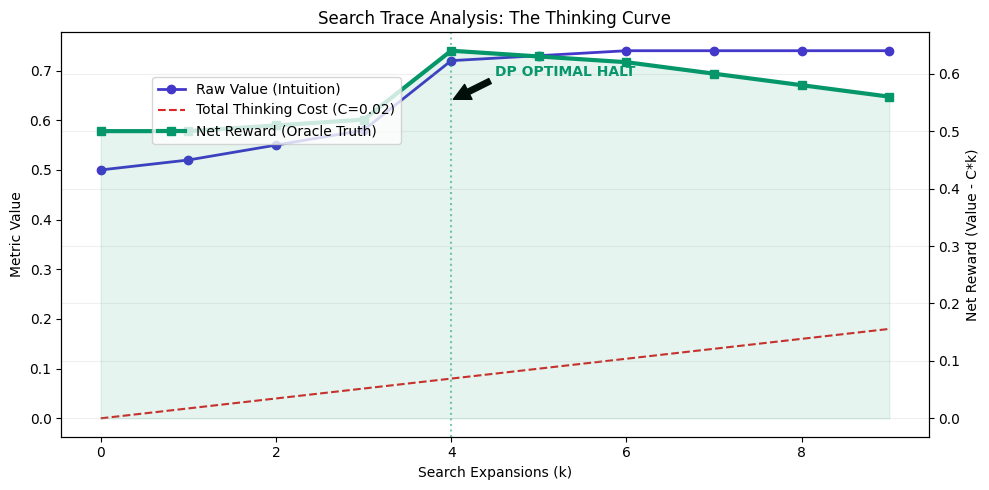

In [3]:
search_values = np.array([0.5, 0.52, 0.55, 0.58, 0.72, 0.73, 0.74, 0.74, 0.74, 0.74])
C = 0.02 

# Visualize the 'Economy of Thought'
visualize_search_trace_dp(search_values, cost_per_step=C)

### Phase 3: The Halt Decision

We pass the GNN summary into the `HaltController`. This MLP maps the high-dimensional chess context into a single probability: $P(\text{halt})$.

Halt Probability (Initial): 0.5170


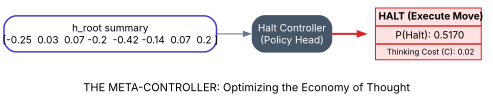

In [4]:
C = 0.02
logits, prob = halt_head(h_root.unsqueeze(0))
prob_val = prob.item()

print(f"Halt Probability (Initial): {prob_val:.4f}")
display(visualize_halt_decision(h_root, prob_val, thinking_cost=C))

### Phase 4: The Meta-Training Loop

Now we see how the Meta-Controller actually learns. We'll simulate a "Mini-Batch" of search fragments and train the `HaltHead` to identify when to stop.

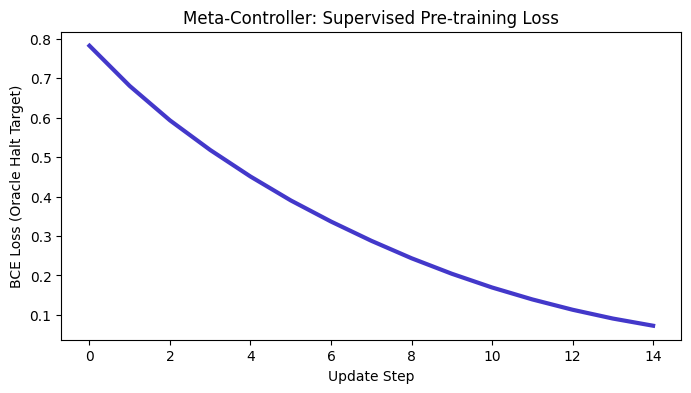

In [5]:
optimizer = torch.optim.Adam(halt_head.parameters(), lr=0.01)
criterion = torch.nn.BCELoss()

demo_h_states = torch.randn(4, 8) 
demo_targets = torch.tensor([0.0, 0.0, 1.0, 1.0]) 

losses = []
for epoch in range(15):
    optimizer.zero_grad()
    logits, probs = halt_head(demo_h_states)
    loss = criterion(probs, demo_targets)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(8, 4))
plt.plot(losses, color='#4338ca', linewidth=3)
plt.title("Meta-Controller: Supervised Pre-training Loss")
plt.xlabel("Update Step")
plt.ylabel("BCE Loss (Oracle Halt Target)")
plt.show()

### Phase 5: Search as a Dynamic Sequence

In a real battle, the GNN doesn't just see one tree. It sees the tree **growing**. Here, we simulate the environment revealing nodes expansion-by-expansion. Watch how the root summary $h_{root}$ and the resulting Halt probability change as context arrives.

In [6]:
growth_snapshots = simulate_environmental_growth()

print(f"ENVIRONMENT: Simulating {len(growth_snapshots)} steps of tree expansion...\n")

for i, snap in enumerate(growth_snapshots):
    batch = tensorizer.tensorize_forest([snap])
    output = gnn(batch)
    h_root = output.root_states[0]
    
    _, prob = halt_head(h_root.unsqueeze(0))
    p_halt = prob.item()
    
    action = "HALT (Play Move)" if p_halt > 0.5 else "CONTINUE (Expand Deep)"
    
    print(f"[Step {i}] Nodes: {len(list(snap.iter_nodes())):<2} | P(Halt): {p_halt:.4f} | Decision: {action}")


ENVIRONMENT: Simulating 2 steps of tree expansion...

[Step 0] Nodes: 2  | P(Halt): 0.7693 | Decision: HALT (Play Move)
[Step 1] Nodes: 3  | P(Halt): 0.7779 | Decision: HALT (Play Move)


## Conclusion: Final Architecture Sync

You have now seen the complete pipeline:
1.  **Tutorial 01-02:** Prepare raw chess search data into flat GPU tensors.
2.  **Tutorial 03-04:** Train a Bidirectional GNN to summarize these trees into predictive latent vectors ($h$).
3.  **Tutorial 05:** Use the GNN's root summary to make optimal, cost-aware decisions about the economy of thought.

This Meta-Controller allows `lmcos` to act as a **Dynamic Intelligence Accelerator**, spending more brain power on complex tactical blunders and skipping trivial forced moves.